In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Dropout, Input, RepeatVector
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
import matplotlib.pyplot as plt
import scikitplot as skplt
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import LSTM, GRU
from keras.layers import Dense , Dropout
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import scikitplot as skplt
from sklearn.preprocessing import label_binarize
from sklearn.datasets import load_digits
#from yellowbrick.features import ParallelCoordinates
from keras.layers import Bidirectional, LSTM
from keras.layers import Bidirectional, GRU
from sklearn.metrics import matthews_corrcoef

In [2]:
filepath= "C:/Users/Theda/Desktop/6G Driven SHS/Edge-iiotset.csv"

In [3]:
mydata= pd.read_csv(filepath)

C:\Users\Theda\AppData\Local\Temp\ipykernel_7476\3114935309.py:1: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  mydata= pd.read_csv(filepath)


In [4]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219201 entries, 0 to 2219200
Data columns (total 63 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   frame.time                 object 
 1   ip.src_host                object 
 2   ip.dst_host                object 
 3   arp.dst.proto_ipv4         object 
 4   arp.opcode                 float64
 5   arp.hw.size                float64
 6   arp.src.proto_ipv4         object 
 7   icmp.checksum              float64
 8   icmp.seq_le                float64
 9   icmp.transmit_timestamp    float64
 10  icmp.unused                float64
 11  http.file_data             object 
 12  http.content_length        float64
 13  http.request.uri.query     object 
 14  http.request.method        object 
 15  http.referer               object 
 16  http.request.full_uri      object 
 17  http.request.version       object 
 18  http.response              float64
 19  http.tls_port              float64
 20  tc

In [5]:
drop_columns = ["frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4","arp.dst.proto_ipv4", 

         "http.file_data","http.request.full_uri","icmp.transmit_timestamp",

         "http.request.uri.query", "tcp.options","tcp.payload","tcp.srcport",

         "tcp.dstport", "udp.port", "mqtt.msg"]

mydata.drop(drop_columns, axis=1, inplace=True)


In [6]:
print(mydata['Attack_type'].value_counts())

Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64


In [7]:
mydata.drop('Attack_label', axis='columns', inplace=True)


In [8]:
mydata.replace([np.inf, -np.inf], np.nan, inplace=True)
mydata.dropna(inplace=True)
mydata.drop_duplicates(inplace=True)
mydata.reset_index(inplace=True, drop=True)
mydata = mydata.sample(frac=1).reset_index(drop=True)

In [9]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927304 entries, 0 to 1927303
Data columns (total 47 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   arp.opcode                 float64
 1   arp.hw.size                float64
 2   icmp.checksum              float64
 3   icmp.seq_le                float64
 4   icmp.unused                float64
 5   http.content_length        float64
 6   http.request.method        object 
 7   http.referer               object 
 8   http.request.version       object 
 9   http.response              float64
 10  http.tls_port              float64
 11  tcp.ack                    float64
 12  tcp.ack_raw                float64
 13  tcp.checksum               float64
 14  tcp.connection.fin         float64
 15  tcp.connection.rst         float64
 16  tcp.connection.syn         float64
 17  tcp.connection.synack      float64
 18  tcp.flags                  float64
 19  tcp.flags.ack              float64
 20  tc

In [10]:
attacks = {'Normal': 0 ,'DDoS_UDP' :1, 'DDoS_ICMP':2, 'SQL_injection':3, 'Password':4,
       'Vulnerability_scanner':5 , 'DDoS_TCP':6, 'DDoS_HTTP':7, 'Uploading':8, 'Backdoor':9, 
       'Port_Scanning':10, 'XSS':11, 'Ransomware':12, 'Fingerprinting':13, 'MITM':14}
mydata['label']=mydata['Attack_type'].map(attacks)

In [11]:
print(mydata['label'].value_counts())

label
0     1380858
1      121567
2       67939
3       50826
6       50062
5       50026
4       49933
7       49203
8       36915
9       24026
10      19983
11      15066
12       9689
13        853
14        358
Name: count, dtype: int64


In [12]:
mydata.drop('Attack_type', axis='columns', inplace=True)

In [13]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

In [14]:
mydata['mqtt.protoname'] = mydata['mqtt.protoname'].astype(str)
mydata['mqtt.topic'] = mydata['mqtt.topic'].astype(str)
mydata['mqtt.conack.flags'] = mydata['mqtt.conack.flags'].astype(str)
mydata['dns.qry.name.len'] = mydata['dns.qry.name.len'].astype(str)
mydata['http.request.method'] = mydata['http.request.method'].astype(str)
mydata['http.referer'] = mydata['http.referer'].astype(str)
mydata['http.request.version'] = mydata['http.request.version'].astype(str)

In [15]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

mydata['mqtt.protoname'] = labelencoder.fit_transform(mydata['mqtt.protoname'])
mydata['mqtt.topic'] = labelencoder.fit_transform(mydata['mqtt.topic'])
mydata['mqtt.conack.flags'] = labelencoder.fit_transform(mydata['mqtt.conack.flags'])
mydata['dns.qry.name.len'] = labelencoder.fit_transform(mydata['dns.qry.name.len'])
mydata['http.request.method'] = labelencoder.fit_transform(mydata['http.request.method'])
mydata['http.referer'] = labelencoder.fit_transform(mydata['http.referer'])
mydata['http.request.version'] = labelencoder.fit_transform(mydata['http.request.version'])


In [16]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927304 entries, 0 to 1927303
Data columns (total 47 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   arp.opcode                 float64
 1   arp.hw.size                float64
 2   icmp.checksum              float64
 3   icmp.seq_le                float64
 4   icmp.unused                float64
 5   http.content_length        float64
 6   http.request.method        int32  
 7   http.referer               int32  
 8   http.request.version       int32  
 9   http.response              float64
 10  http.tls_port              float64
 11  tcp.ack                    float64
 12  tcp.ack_raw                float64
 13  tcp.checksum               float64
 14  tcp.connection.fin         float64
 15  tcp.connection.rst         float64
 16  tcp.connection.syn         float64
 17  tcp.connection.synack      float64
 18  tcp.flags                  float64
 19  tcp.flags.ack              float64
 20  tc

In [17]:
X = mydata.iloc[:, 0:46]
Y = mydata.iloc[:, 46:47]

In [18]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X = sc.fit_transform(X)

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)
x_train = np.array(x_train)
x_train = np.reshape (x_train,(x_train.shape[0], 1, x_train.shape[1]))
#Reshape and normalize test data
x_test = np.array(x_test)
x_test = np.reshape (x_test,(x_test.shape[0], 1, x_test.shape[1]))

In [20]:
Num_classes = len(np.unique(Y))
y_train_ohe=to_categorical(y_train,Num_classes)
y_train_ohe = pd.DataFrame(y_train_ohe)

In [21]:
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf

In [22]:
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

In [23]:
beta = 4.0  # (beta >= 1)

In [24]:
input_dim = x_train.shape[2]  # This should be 8, representing data[0] to data[7]
inputs = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(inputs)
z_mean = Dense(32)(encoded)
z_log_var = Dense(32)(encoded)

In [25]:
z = Lambda(sampling, output_shape=(32,))([z_mean, z_log_var])

In [26]:
decoded = Dense(64, activation='relu')(z)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

In [27]:
vae = Model(inputs, decoded)

In [28]:
class KLLossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(KLLossLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
        self.add_loss(beta * K.mean(kl_loss))  # Add the KL loss to the final model loss
        return z_mean


In [29]:
z_mean_kl_loss = KLLossLayer()([z_mean, z_log_var])

In [30]:
def beta_vae_loss(inputs, decoded):
    # Reconstruction loss (Mean Squared Error)
    reconstruction_loss = K.mean(K.square(inputs - decoded), axis=-1)
    return reconstruction_loss  # KL loss is added automatically

In [31]:
vae.compile(optimizer='adam', loss=beta_vae_loss)

In [32]:
# Reshape x_train to match the expected input shape (batch_size, input_dim)
x_train_flattened = x_train.reshape((x_train.shape[0], x_train.shape[2]))

In [33]:
# Train the Beta-VAE
betahistory=vae.fit(x_train_flattened, x_train_flattened, epochs=20, batch_size=64, validation_split=0.5)

Epoch 1/20
10540/10540 [==============================] - 31s 3ms/step - loss: 0.7149 - val_loss: 0.6265
Epoch 2/20
10540/10540 [==============================] - 36s 3ms/step - loss: 0.7106 - val_loss: 0.6246
Epoch 3/20
10540/10540 [==============================] - 35s 3ms/step - loss: 0.7094 - val_loss: 0.6242
Epoch 4/20
10540/10540 [==============================] - 34s 3ms/step - loss: 0.7090 - val_loss: 0.6242
Epoch 5/20
10540/10540 [==============================] - 33s 3ms/step - loss: 0.7090 - val_loss: 0.6242
Epoch 6/20
10540/10540 [==============================] - 30s 3ms/step - loss: 0.7090 - val_loss: 0.6242
Epoch 7/20
10540/10540 [==============================] - 34s 3ms/step - loss: 0.7090 - val_loss: 0.6242
Epoch 8/20
10540/10540 [==============================] - 35s 3ms/step - loss: 0.7090 - val_loss: 0.6242
Epoch 9/20
10540/10540 [==============================] - 35s 3ms/step - loss: 0.7089 - val_loss: 0.6242
Epoch 10/20
10540/10540 [==============================

In [34]:
# Use the encoder part for feature extraction
encoder = Model(inputs, z_mean)  # Use the mean as the encoded representation
x_train_encoded = encoder.predict(x_train_flattened)
x_test_encoded = encoder.predict(x_test.reshape((x_test.shape[0], x_test.shape[2])))

x_train_encoded = np.reshape(x_train_encoded, (x_train_encoded.shape[0], 1, x_train_encoded.shape[1]))
x_test_encoded = np.reshape(x_test_encoded, (x_test_encoded.shape[0], 1, x_test_encoded.shape[1]))


18069/18069 [==============================] - 33s 2ms/step


In [35]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Attention, Input, Dense, LSTM, Bidirectional, Conv1D, LayerNormalization, Add, Dropout, Concatenate, Flatten
from tensorflow.keras.models import Model

# Enhanced Multi-Scale Multi-Head Attention Layer
class MultiScaleMultiHeadAttention(Layer):
    def __init__(self, num_heads=4, scales=[1, 2, 4], feature_dim=None, **kwargs):
        super(MultiScaleMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.scales = scales
        self.conv_layers = [
            [Conv1D(filters=feature_dim, kernel_size=scale, padding='same', activation='relu')
             for _ in range(num_heads)] for scale in scales]
        self.attention_heads = [[Attention() for _ in range(num_heads)] for _ in self.scales]
        self.fusion_layer = Dense(feature_dim * len(scales) * num_heads, activation='sigmoid')

    def call(self, x):
        multi_scale_outputs = []
        for scale_idx, (scale_heads, scale_conv_layers) in enumerate(zip(self.attention_heads, self.conv_layers)):
            for head_idx, (attention, conv) in enumerate(zip(scale_heads, scale_conv_layers)):
                conv_x = conv(x)
                attention_output = attention([conv_x, conv_x])
                multi_scale_outputs.append(attention_output)
        
        concatenated = Concatenate(axis=-1)(multi_scale_outputs)
        fusion_weight = self.fusion_layer(concatenated)
        fused_output = concatenated * fusion_weight
        return fused_output
        
# Residual BiLSTM block with matching dimensions
def residual_bilstm_block(x, units):
    x_res = x  # Save residual connection
    x = Bidirectional(LSTM(units, activation='relu', return_sequences=True))(x)
    x = LayerNormalization()(x)
    
    # Match dimensions of residual connection using a Dense layer
    x_res = Dense(units * 2)(x_res)  # Since Bidirectional doubles the units
    x = Add()([x, x_res])  # Adding the residual connection
    return x

# Assuming x_train_encoded.shape[2] gives the number of features per timestep
num_features = x_train_encoded.shape[2]  # You should define x_train_encoded.shape[2] before this script

# Define the enhanced model with Multi-Scale Temporal Attention and Adaptive Feature Fusion
inputs = Input(shape=(x_train_encoded.shape[1], x_train_encoded.shape[2]))
x = Bidirectional(LSTM(80, activation='relu', return_sequences=True))(inputs)

# Adding residual BiLSTM blocks with dimension matching
x = residual_bilstm_block(x, 32)
x = residual_bilstm_block(x, 16)

x = Dropout(0.2)(x)
# Multi-Scale Multi-Head Attention
x = MultiScaleMultiHeadAttention(num_heads=4, scales=[1, 2, 4], feature_dim=num_features)(x)
x = Flatten()(x)  # Flatten to ensure the output dimension is correct
x = Dropout(rate=0.2)(x)
outputs = Dense(15, activation='softmax')(x)  # Update Num_classes to your actual number of classes

model = Model(inputs=inputs, outputs=outputs)
# Compile with AdamW and custom learning rate schedule
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-4, weight_decay=1e-4), metrics=['accuracy'])

# Custom learning rate schedule
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [36]:
history = model.fit(x_train_encoded, y_train_ohe, epochs=20, validation_split=0.5, batch_size=64, callbacks=[lr_schedule])

Epoch 1/20
10540/10540 [==============================] - 473s 43ms/step - loss: 0.1508 - accuracy: 0.9328 - val_loss: 0.1212 - val_accuracy: 0.9420 - lr: 2.0000e-04
Epoch 2/20
10540/10540 [==============================] - 432s 41ms/step - loss: 0.1202 - accuracy: 0.9431 - val_loss: 0.1082 - val_accuracy: 0.9475 - lr: 2.0000e-04
Epoch 3/20
10540/10540 [==============================] - 426s 40ms/step - loss: 0.1123 - accuracy: 0.9463 - val_loss: 0.1078 - val_accuracy: 0.9478 - lr: 2.0000e-04
Epoch 4/20
10540/10540 [==============================] - 434s 41ms/step - loss: 0.1102 - accuracy: 0.9466 - val_loss: 0.1062 - val_accuracy: 0.9482 - lr: 2.0000e-04
Epoch 5/20
10540/10540 [==============================] - 423s 40ms/step - loss: 0.1097 - accuracy: 0.9470 - val_loss: 0.1072 - val_accuracy: 0.9479 - lr: 2.0000e-04
Epoch 6/20
10540/10540 [==============================] - 430s 41ms/step - loss: 0.1095 - accuracy: 0.9470 - val_loss: 0.1079 - val_accuracy: 0.9479 - lr: 2.0000e-04
Epoc

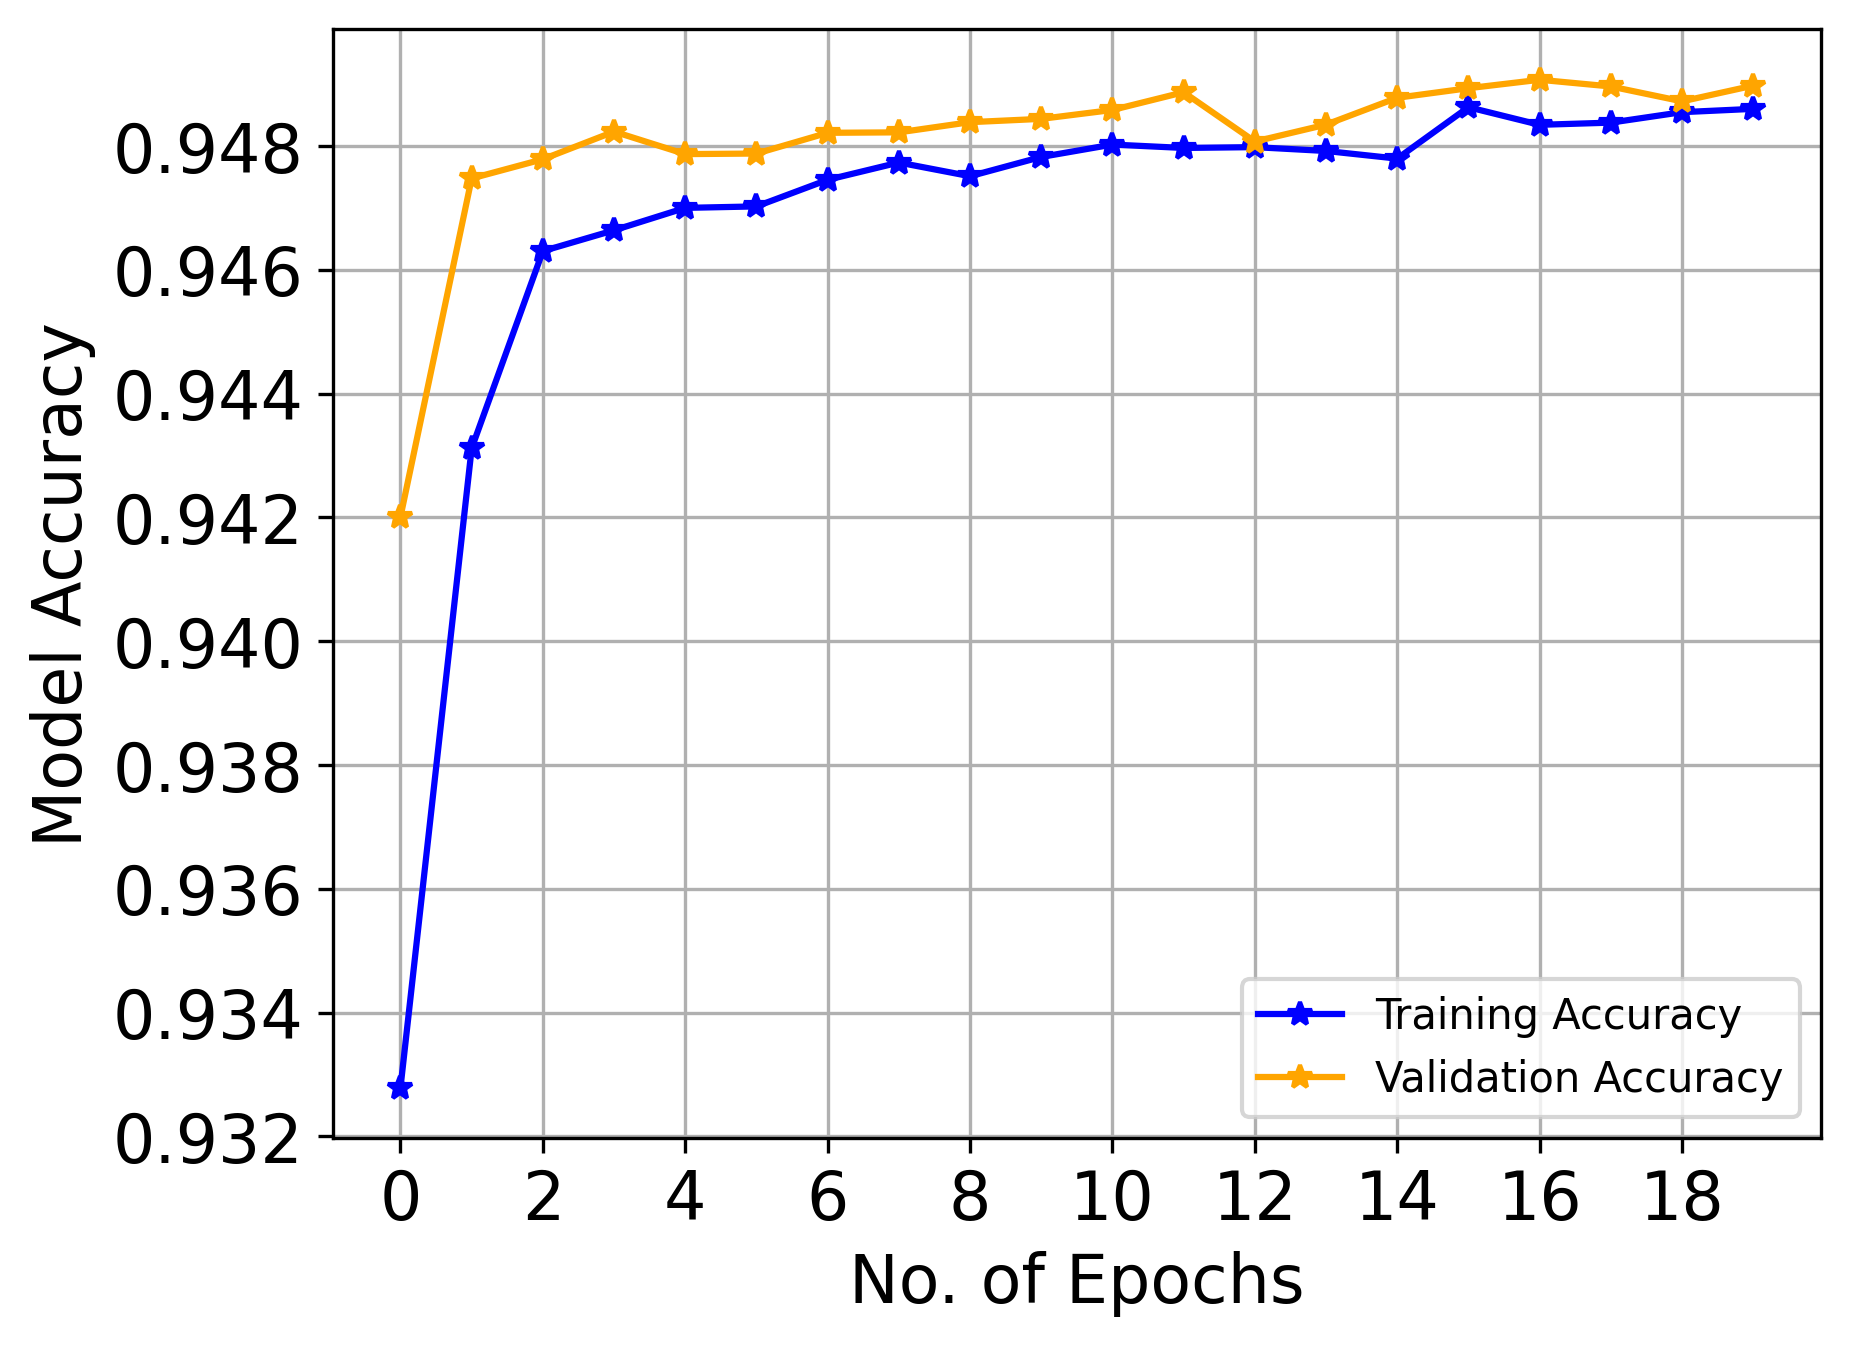

In [67]:
epochs = len(history.history['accuracy'])
plt.plot(history.history['accuracy'], label='Training Accuracy', color="blue", marker='*')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color="orange", marker='*')
# plt.title('Model loss')  # Commented out as it seems you don't want the title
plt.ylabel('Model Accuracy', fontsize=16)
plt.xlabel('No. of Epochs', fontsize=16)
plt.rcParams['figure.dpi'] = 300
plt.legend()
plt.grid()  # Commented out as it seems you don't want the grid
# Set the ticks on the x-axis to 2, 4, and 6
plt.xticks(np.arange(0, epochs, step=2), fontsize=16)  # Adjust the step size as needed
plt.yticks(fontsize=16)
# plt.rcParams['figure.figsize'] = [6.0, 4.0]  # Commented out as it seems you have another setting for figure size
plt.savefig('edgeencodoracc.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


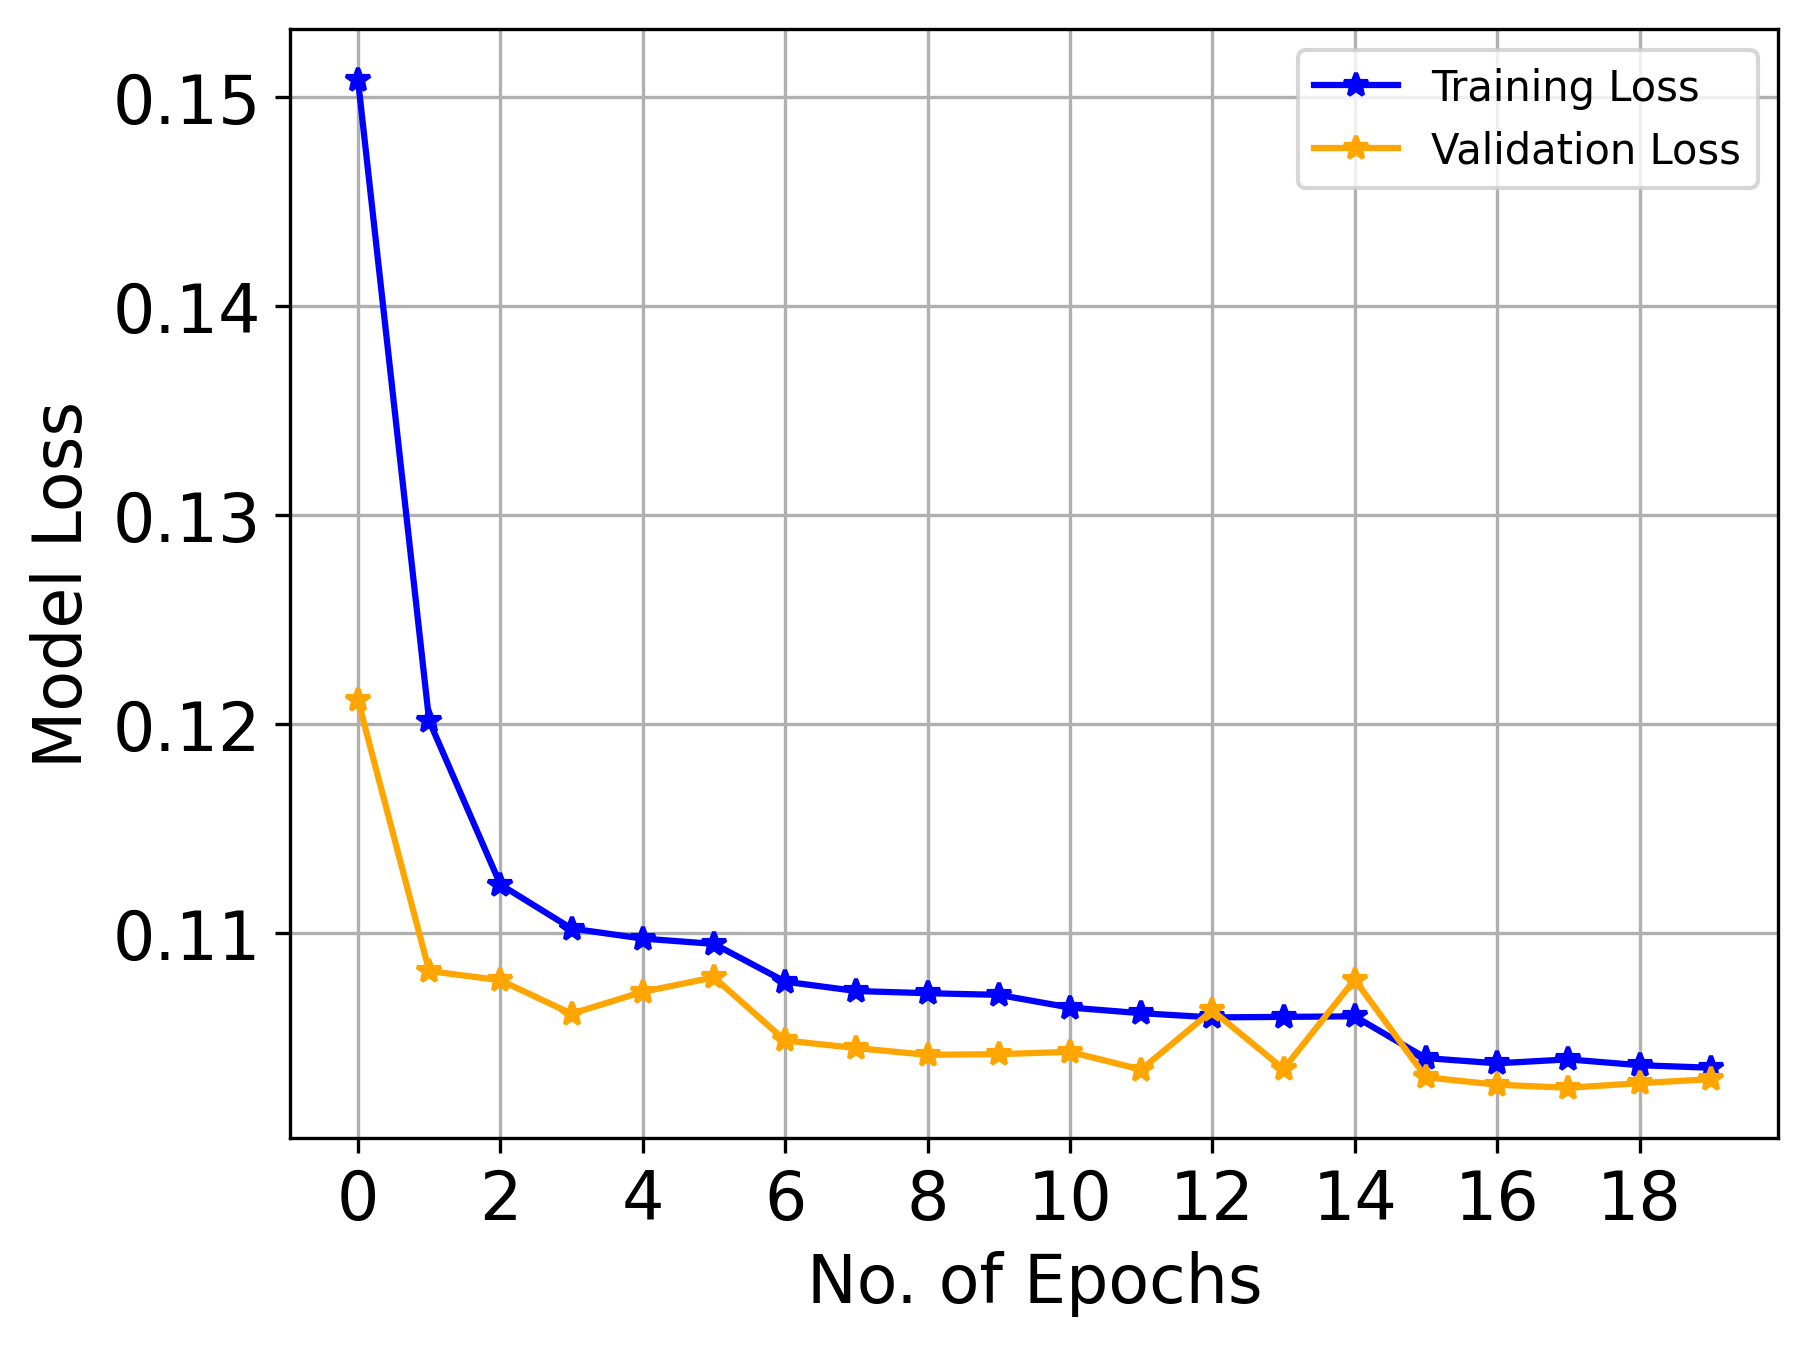

In [68]:
epochs = len(history.history['loss'])
plt.plot(history.history['loss'], label='Training Loss', color="blue", marker='*')
plt.plot(history.history['val_loss'], label='Validation Loss', color="orange", marker='*')
# plt.title('Model loss')  # Commented out as it seems you don't want the title
plt.ylabel('Model Loss', fontsize=16)
plt.xlabel('No. of Epochs', fontsize=16)
plt.rcParams['figure.dpi'] = 300
plt.legend()
plt.grid()  # Commented out as it seems you don't want the grid
# Set the ticks on the x-axis to 2, 4, and 6
plt.xticks(np.arange(0, epochs, step=2), fontsize=16)  # Adjust the step size as needed
plt.yticks(fontsize=16)
# plt.rcParams['figure.figsize'] = [6.0, 4.0]  # Commented out as it seems you have another setting for figure size
plt.savefig('edgeencoderloss.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
predict_prob=model.predict([x_test_encoded])
predict_classes=np.argmax(predict_prob,axis=1)
prediction = model.predict(x_test_encoded)
prediction =prediction.argmax(1)

18069/18069 [==============================] - 62s 3ms/step


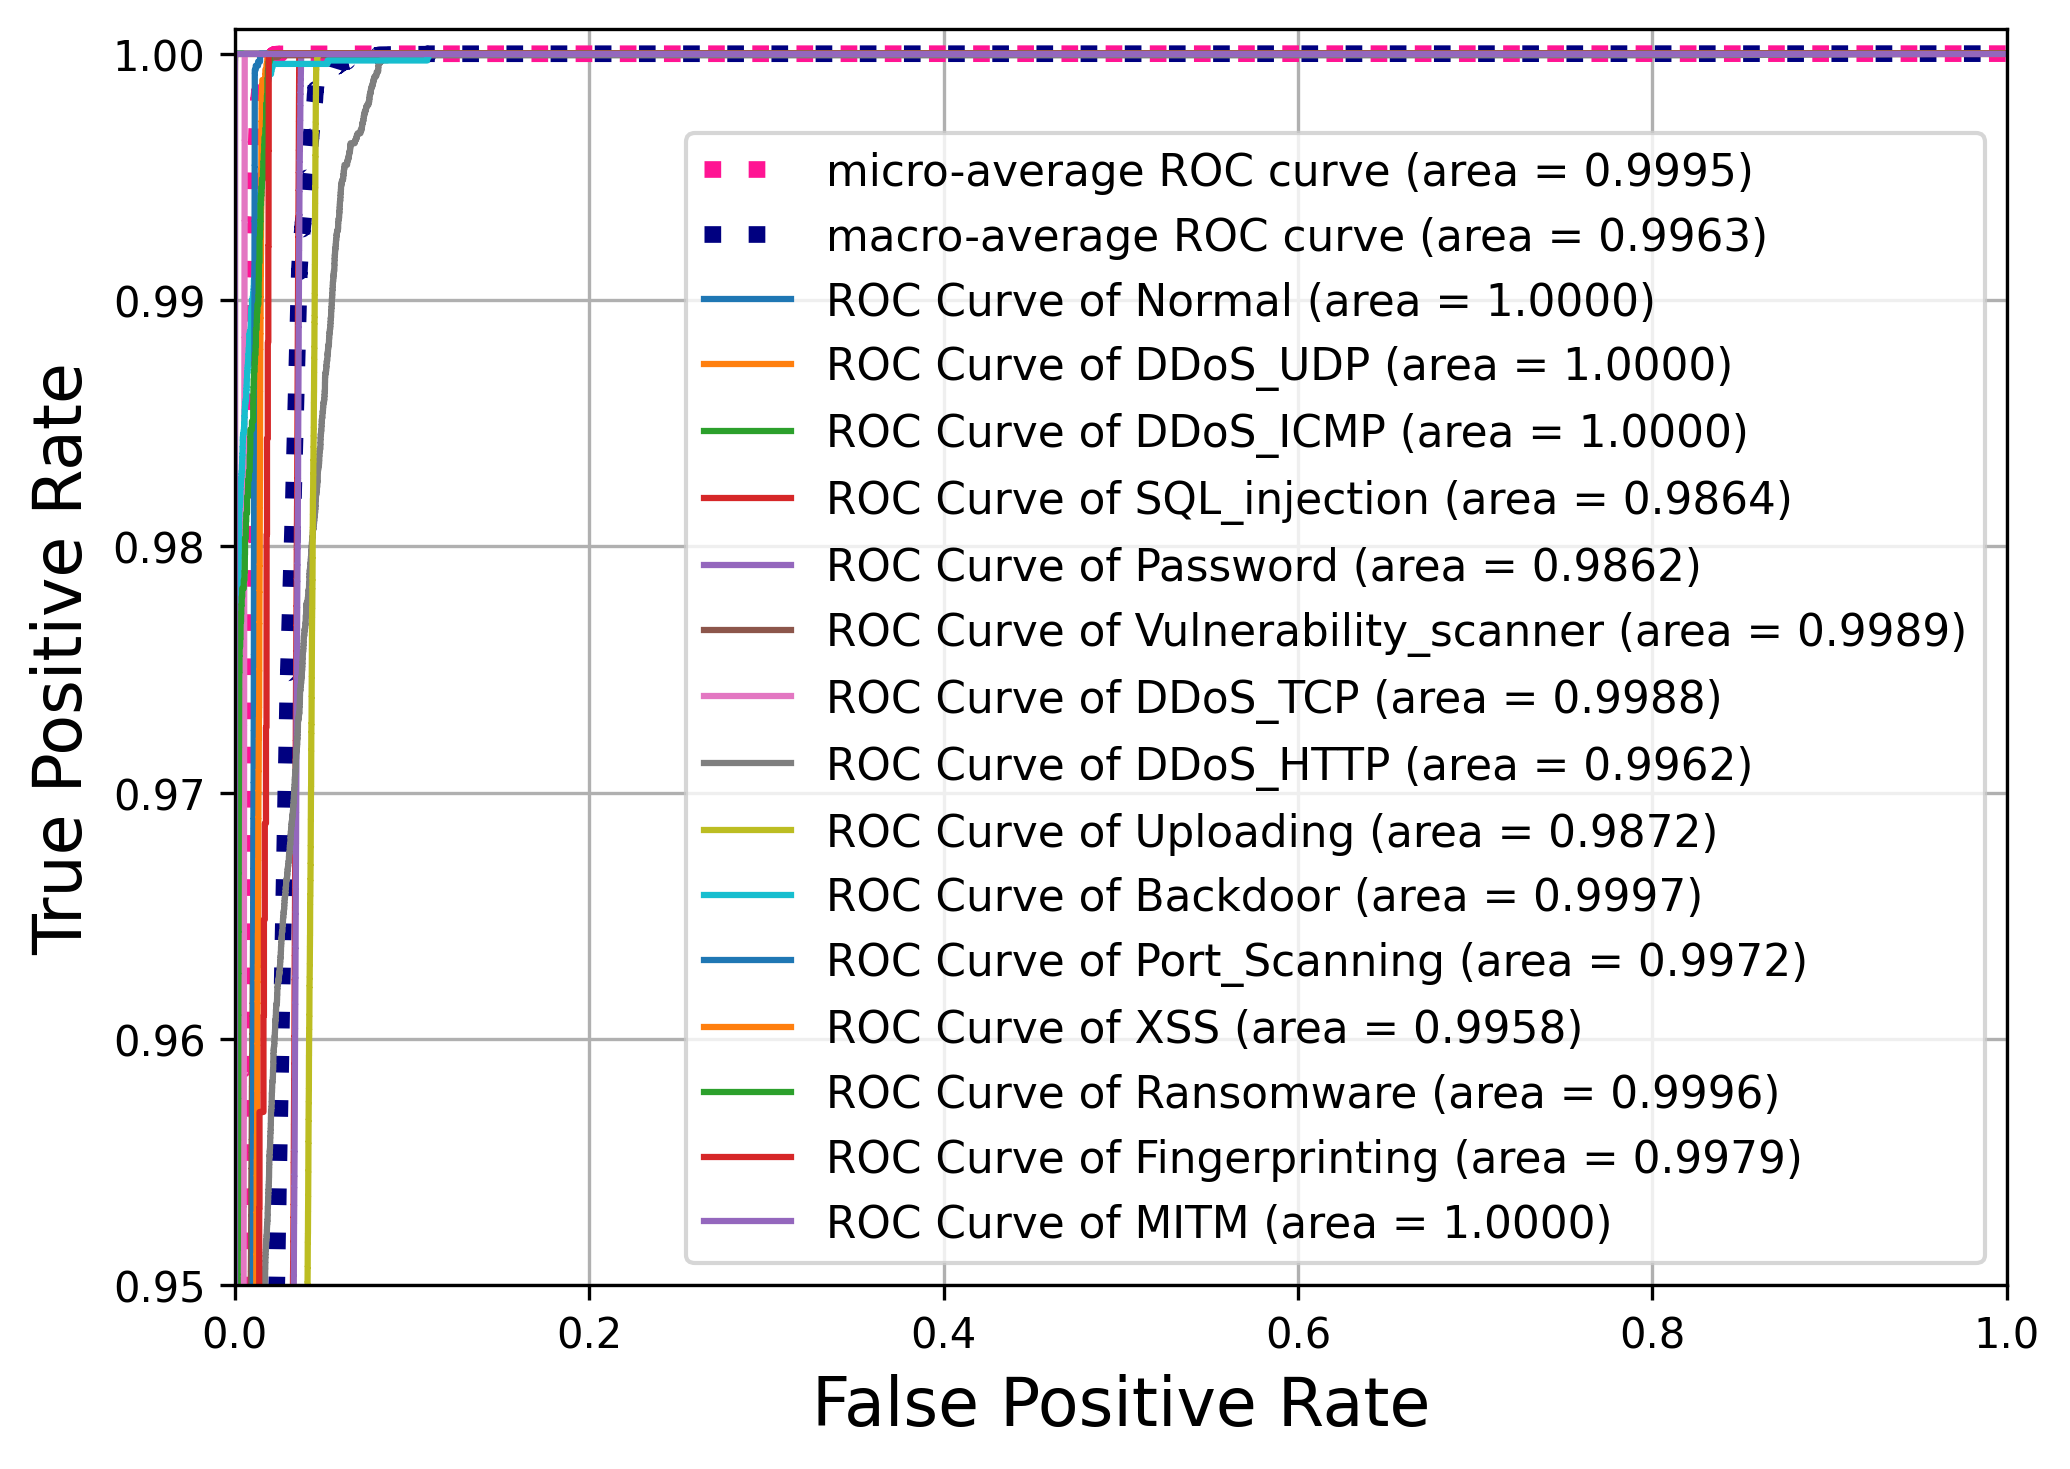

In [49]:
from sklearn.preprocessing import label_binarize
# Assuming y_test and predict_prob are already defined
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.arange(Num_classes))
# Class names (modify these names as per your actual class names)
class_names = ['Normal','DDoS_UDP', 'DDoS_ICMP', 'SQL_injection', 'Password',
       'Vulnerability_scanner', 'DDoS_TCP', 'DDoS_HTTP', 'Uploading', 
       'Backdoor','Port_Scanning', 'XSS', 'Ransomware', 
       'Fingerprinting', 'MITM']
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(Num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], predict_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), predict_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(Num_classes)]))
# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(Num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
# Finally average it and compute AUC
mean_tpr /= Num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
# Plot ROC curves for each class, micro-average, and macro-average
plt.figure(figsize=(7, 5))  # Increase figure size for better visibility
# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=4)
# Plot macro-average ROC curve
plt.plot(fpr["macro"], tpr["macro"],
         label=f'macro-average ROC curve (area = {roc_auc["macro"]:.4f})',
         color='navy', linestyle=':', linewidth=4)
# Plot ROC curve for each class
for i in range(Num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC Curve of {class_names[i]} (area = {roc_auc[i]:.4f})')
# Plot the diagonal line
#plt.plot([0, 1], [0, 1], 'k--')
# Set the limits from 0.9 to 1.0
plt.xlim([0.0, 1.0])
plt.ylim([0.95, 1.001])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
#plt.title('Receiver Operating Characteristic (Zoomed In)')
# Place the legend inside the plot area
plt.legend(loc='lower right', fontsize=10.5, title_fontsize='xx-large')
plt.grid()
plt.tight_layout()  # Adjust subplots to give space for the legend
plt.savefig('edgeencoderroc.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
print("Accuracy:" + str(accuracy_score(y_test, prediction)* 100)) 
print(precision_score(y_test, prediction, average="macro"))  
print(recall_score(y_test, prediction, average="macro"))
print(f1_score(y_test, prediction, average="macro"))

Accuracy:94.87125383955502
0.8536545835715994
0.7839608161232863
0.7881975470972239


In [43]:
print(precision_score(y_test, prediction, average="weighted"))  
print(recall_score(y_test, prediction, average="weighted"))
print(f1_score(y_test, prediction, average="weighted"))

0.9617309903931516
0.9487125383955503
0.9449333021217486


In [44]:
print(classification_report(y_test, prediction))
cm = confusion_matrix(y_test, prediction)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    413883
           1       1.00      1.00      1.00     36427
           2       1.00      1.00      1.00     20370
           3       0.45      0.91      0.60     15228
           4       0.92      0.18      0.30     14909
           5       1.00      0.84      0.91     15187
           6       0.82      1.00      0.90     14966
           7       0.73      0.90      0.81     14842
           8       0.65      0.49      0.56     11062
           9       0.98      0.95      0.96      7192
          10       1.00      0.51      0.68      6143
          11       0.63      0.44      0.52      4673
          12       0.97      0.88      0.92      2948
          13       0.66      0.66      0.66       256
          14       1.00      1.00      1.00       106

    accuracy                           0.95    578192
   macro avg       0.85      0.78      0.79    578192
weighted avg       0.96   

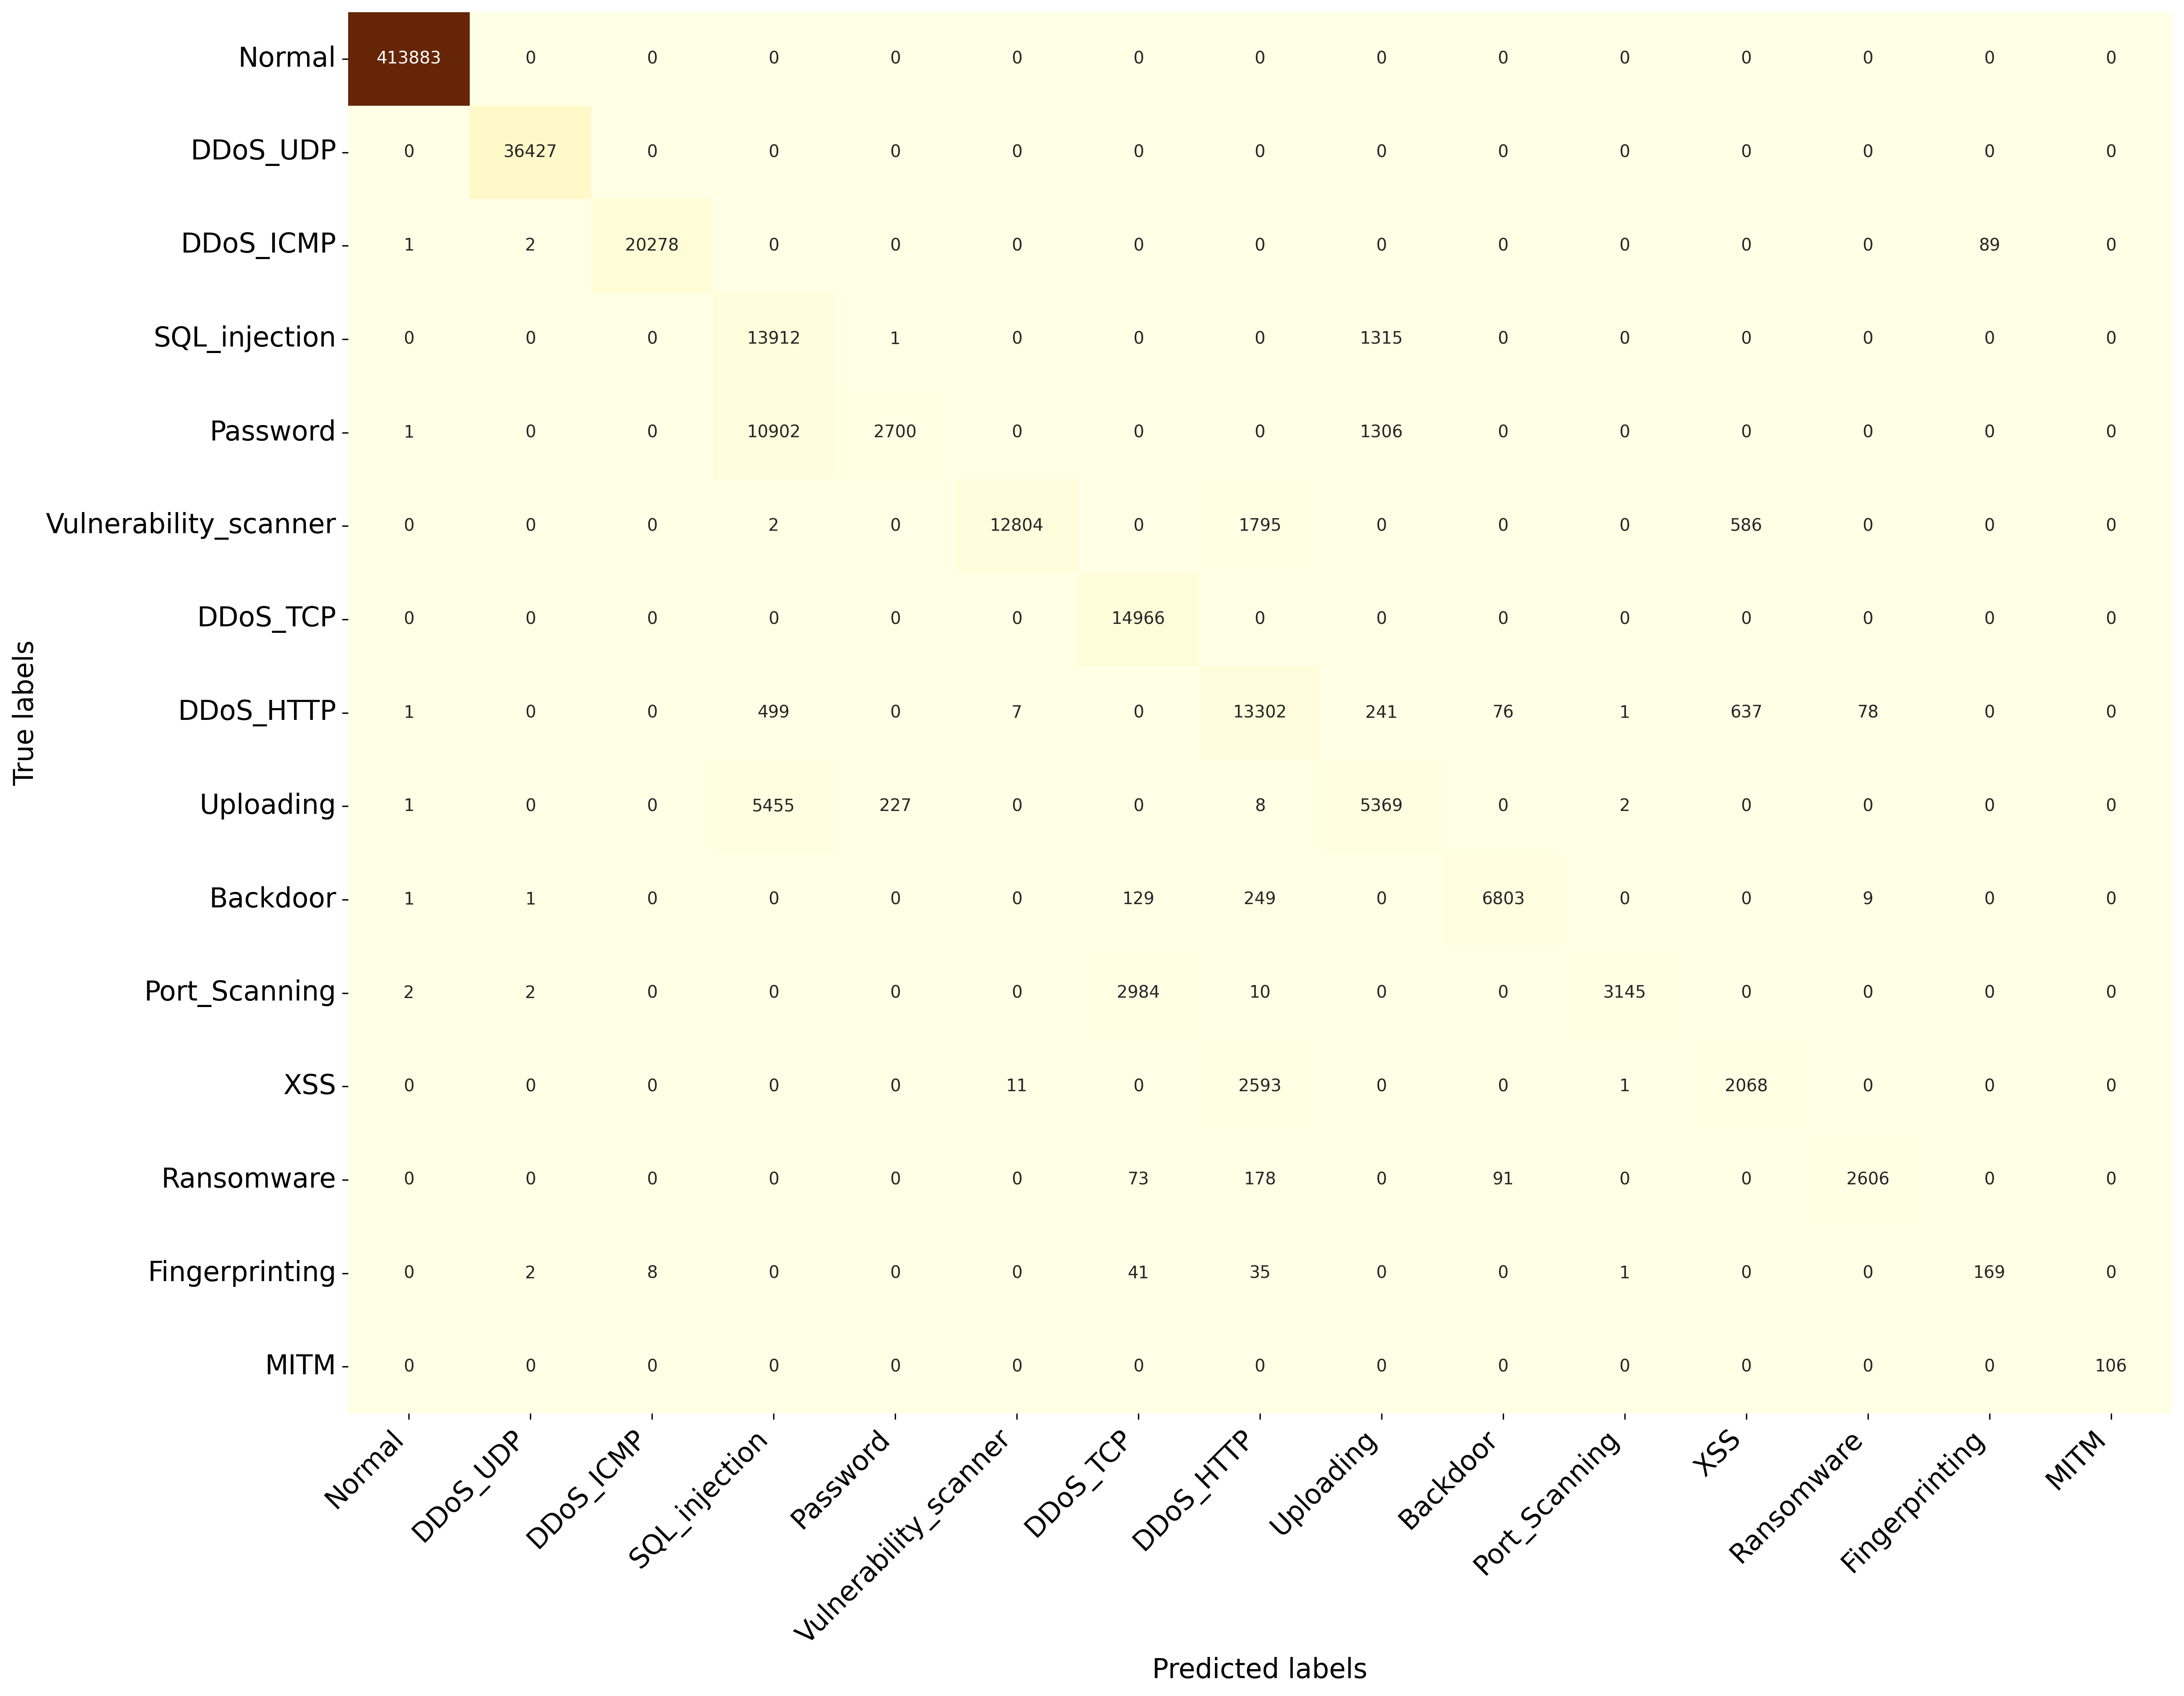

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Class names
class_names = ['Normal', 'DDoS_UDP', 'DDoS_ICMP', 'SQL_injection', 'Password',
               'Vulnerability_scanner', 'DDoS_TCP', 'DDoS_HTTP', 'Uploading',
               'Backdoor', 'Port_Scanning', 'XSS', 'Ransomware',
               'Fingerprinting', 'MITM']

# Assuming y_test and prediction are defined elsewhere
# Calculate the confusion matrix
cm = confusion_matrix(y_test, prediction)
# Create a custom colormap
cmap = sns.color_palette("YlOrBr", as_cmap=True)  # Use a yellow-orange-brown gradient
# Plot the confusion matrix using seaborn
plt.figure(figsize=(18, 14))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.xlabel('Predicted labels', fontsize=16)
plt.ylabel('True labels', fontsize=16)
#plt.title('Confusion Matrix')
plt.tight_layout()  # Adjust layout to make room for rotated x labels
plt.savefig('edgeencodercm.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Set the resolution of the figure
plt.rcParams['figure.dpi'] = 300

Normalized Confusion Matrix:
 [[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.90918017e-05 9.81836033e-05 9.95483554e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.36917035e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 9.13580247e-01
  6.56685054e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
  8.63540846e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.70735797e-05 0.00000000e+00 0.

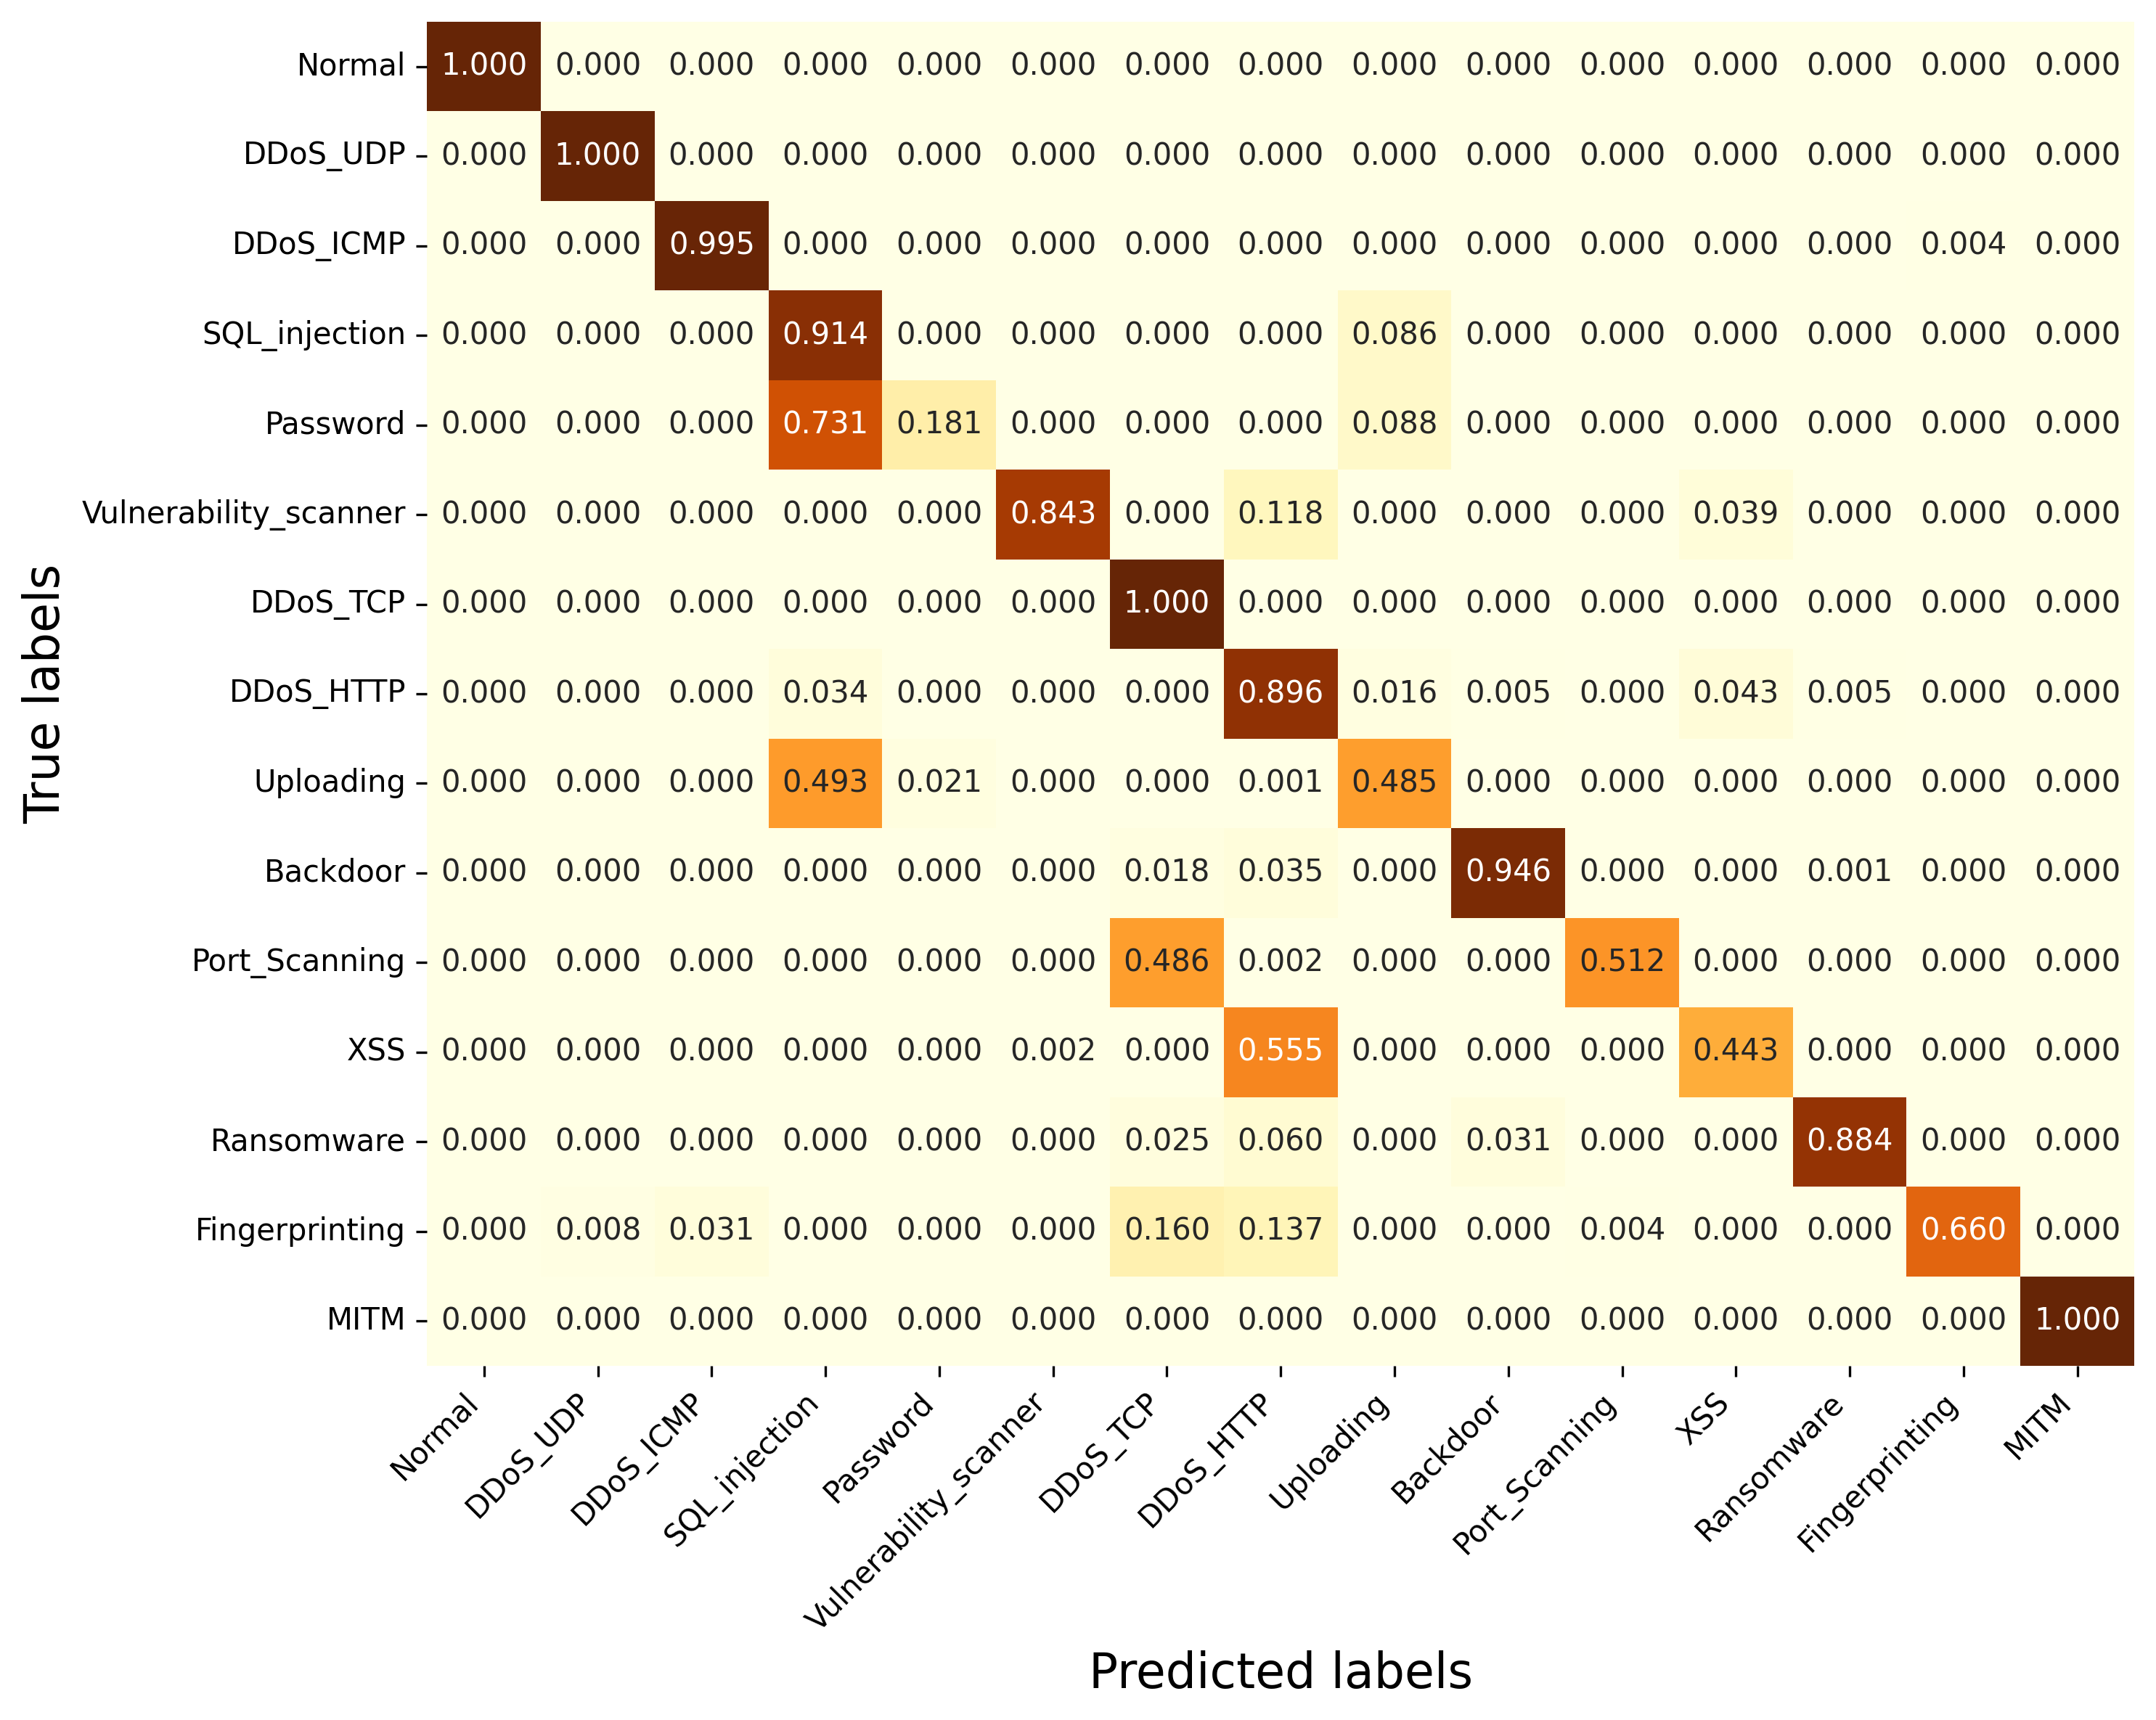

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Class names
class_names = ['Normal', 'DDoS_UDP', 'DDoS_ICMP', 'SQL_injection', 'Password',
               'Vulnerability_scanner', 'DDoS_TCP', 'DDoS_HTTP', 'Uploading',
               'Backdoor', 'Port_Scanning', 'XSS', 'Ransomware',
               'Fingerprinting', 'MITM']

# Assuming y_test and prediction are defined elsewhere
# Calculate the confusion matrix
cm = confusion_matrix(y_test, prediction)

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create a custom colormap
cmap = sns.color_palette("YlOrBr", as_cmap=True)  # Use a yellow-orange-brown gradient

# Plot the normalized confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap=cmap, xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('Predicted labels', fontsize=16)
plt.ylabel('True labels', fontsize=16)
#plt.title('Normalized Confusion Matrix')
plt.tight_layout()  # Adjust layout to make room for rotated x labels
# Print the normalized confusion matrix for reference
print("Normalized Confusion Matrix:\n", cm_normalized)
plt.savefig('edgeencodecmnoramlized.png', format='png', dpi=300, bbox_inches='tight')
plt.show()
# Set the resolution of the figure for better output quality
plt.rcParams['figure.dpi'] = 300


In [53]:
FP = cm.sum(axis=0) - np.diag(cm)  
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)
FP = FP.astype(float)
FN = FN.astype(float)
TP = TP.astype(float)
TN = TN.astype(float)
TPR = TP/(TP+FN)
TNR = TN/(TN+FP) 
FPR = FP/(FP+TN)
FNR = FN/(TP+FN)
FDR = FP/(TP+FP)
FOR = FN/(FN+TN)
PPV = TP/(TP+FP)
NPV = TN/(TN+FN)
# Overall accuracy
ACC = (TP+TN)/(TP+FP+FN+TN)
Precision  = TP / (FP + TP)
Recall = TP / (FN + TP)
F1 = 2* Precision * Recall/ (Precision + Recall )
MCC=matthews_corrcoef(y_test, prediction)

In [54]:
FDR = FP / (TP + FP + 1e-10)
PPV = TP / (TP + FP + 1e-10)
Precision = TP / (FP + TP + 1e-10)

In [55]:
Precision

array([0.99998309, 0.99980787, 0.99960564, 0.4521287 , 0.92213115,
       0.99859616, 0.82262409, 0.73208586, 0.65229012, 0.97604017,
       0.9984127 , 0.62838043, 0.96769402, 0.65503876, 1.        ])

In [56]:
Recall

array([1.        , 1.        , 0.99548355, 0.91358025, 0.18109867,
       0.84308948, 1.        , 0.8962404 , 0.48535527, 0.94591212,
       0.51196484, 0.44254226, 0.88398915, 0.66015625, 1.        ])

In [57]:
F1

array([0.99999154, 0.99990393, 0.99754034, 0.60489587, 0.30274149,
       0.91427755, 0.90268102, 0.80588877, 0.55657492, 0.96074001,
       0.67685355, 0.51933702, 0.92394965, 0.65758755, 1.        ])

In [58]:
FPR

array([4.26026572e-05, 1.29207313e-05, 1.43414924e-05, 2.99450764e-02,
       4.04769894e-04, 3.19712969e-05, 5.72949402e-03, 8.64116446e-03,
       5.04646201e-03, 2.92469352e-04, 8.74050999e-06, 2.13244897e-03,
       1.51240169e-04, 1.53996290e-04, 0.00000000e+00])

In [59]:
TPR

array([1.        , 1.        , 0.99548355, 0.91358025, 0.18109867,
       0.84308948, 1.        , 0.8962404 , 0.48535527, 0.94591212,
       0.51196484, 0.44254226, 0.88398915, 0.66015625, 1.        ])

In [60]:
TNR

array([0.9999574 , 0.99998708, 0.99998566, 0.97005492, 0.99959523,
       0.99996803, 0.99427051, 0.99135884, 0.99495354, 0.99970753,
       0.99999126, 0.99786755, 0.99984876, 0.999846  , 1.        ])

In [61]:
FOR

array([0.        , 0.        , 0.0001649 , 0.002404  , 0.0212233 ,
       0.00421494, 0.        , 0.00274989, 0.0099884 , 0.000681  ,
       0.00521353, 0.00453121, 0.00059427, 0.00015054, 0.        ])

In [62]:
FDR

array([1.69127063e-05, 1.92128232e-04, 3.94360643e-04, 5.47871303e-01,
       7.78688525e-02, 1.40383715e-03, 1.77375914e-01, 2.67914144e-01,
       3.47709877e-01, 2.39598278e-02, 1.58730159e-03, 3.71619569e-01,
       3.23059785e-02, 3.44961240e-01, 0.00000000e+00])

In [63]:
FNR

array([0.        , 0.        , 0.00451645, 0.08641975, 0.81890133,
       0.15691052, 0.        , 0.1037596 , 0.51464473, 0.05408788,
       0.48803516, 0.55745774, 0.11601085, 0.33984375, 0.        ])

In [64]:
MCC

0.8939330081919898

In [65]:
import time
batch_size = 32
_ = model.predict(x_test_encoded, batch_size=batch_size)
num_runs = 5
total_time = 0
for _ in range(num_runs):
    start_time = time.time()
    _ = model.predict(x_test_encoded, batch_size=batch_size)
    total_time += time.time() - start_time
average_batch_prediction_time = total_time / num_runs
total_samples = x_test.shape[0]
average_inference_time_per_sample = average_batch_prediction_time / total_samples
print(f"Average Total Time for Batch Prediction (over {num_runs} runs): {average_batch_prediction_time:.4f} seconds")
print(f"Average Inference Time per Sample: {average_inference_time_per_sample:.6f} seconds")

18069/18069 [==============================] - 118s 7ms/step
Average Total Time for Batch Prediction (over 5 runs): 119.9019 seconds
Average Inference Time per Sample: 0.000207 seconds


In [66]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 1, 32)]              0         []                            
                                                                                                  
 bidirectional (Bidirection  (None, 1, 160)               72320     ['input_2[0][0]']             
 al)                                                                                              
                                                                                                  
 bidirectional_1 (Bidirecti  (None, 1, 64)                49408     ['bidirectional[0][0]']       
 onal)                                                                                            
                                                                                            